# Práctica 1: Relación entre la PDF y la CDF de una Variable Aleatoria Continua

**Curso:** Probabilidad — Licenciatura en Matemáticas Aplicadas  
**Tema:** Variables aleatorias continuas

---

## Objetivos

Al finalizar esta práctica, el estudiante será capaz de:

1. Distinguir entre la **función de densidad de probabilidad (PDF)** y la **función de distribución acumulada (CDF)** de una variable aleatoria continua.
2. Verificar **numérica y gráficamente** la relación integral/diferencial entre la PDF y la CDF:
$$F_X(x) = \int_{-\infty}^{x} f_X(t)\, dt, \qquad f_X(x) = \frac{d}{dx} F_X(x).$$
3. Calcular probabilidades de intervalos $\mathbb{P}(a \leq X \leq b)$ por dos vías equivalentes: como área bajo la PDF y como diferencia de la CDF.
4. Aplicar estos conceptos a las distribuciones **Uniforme**, **Exponencial** y **Normal**.

---

## 1. Marco teórico

### 1.1 Variable aleatoria continua

Una variable aleatoria $X$ se dice **continua** si existe una función $f_X:\mathbb{R}\to[0,\infty)$, llamada **función de densidad de probabilidad (PDF)**, tal que para todo intervalo $[a,b]$,
$$\mathbb{P}(a \leq X \leq b) = \int_a^b f_X(x)\, dx.$$

La PDF debe satisfacer:

- **No negatividad:** $f_X(x) \geq 0$ para todo $x \in \mathbb{R}$.
- **Normalización:** $\displaystyle\int_{-\infty}^{\infty} f_X(x)\, dx = 1.$

> **Observación.** A diferencia del caso discreto, $f_X(x)$ **no** es una probabilidad: puede tomar valores mayores que 1. Lo que tiene interpretación probabilística es el área bajo $f_X$.

### 1.2 Función de distribución acumulada (CDF)

La **función de distribución acumulada** de $X$ se define como
$$F_X(x) = \mathbb{P}(X \leq x) = \int_{-\infty}^{x} f_X(t)\, dt.$$

Sus propiedades fundamentales son:

- $F_X$ es **no decreciente**.
- $\displaystyle\lim_{x\to -\infty} F_X(x) = 0$ y $\displaystyle\lim_{x\to +\infty} F_X(x) = 1$.
- $F_X$ es **continua** (en el caso continuo, además es absolutamente continua).

### 1.3 Relación entre PDF y CDF

Por el **Teorema Fundamental del Cálculo**, en todo punto $x$ donde $f_X$ es continua,
$$\boxed{\; f_X(x) = \dfrac{d}{dx} F_X(x). \;}$$

Adicionalmente, para $a < b$:
$$\mathbb{P}(a < X \leq b) = F_X(b) - F_X(a) = \int_a^b f_X(x)\, dx.$$

Esta es la **doble vía** que usaremos para verificar todo: integrar la densidad o restar la acumulada.

## 2. Preparación del entorno

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, integrate

# Ajustes de visualización
plt.rcParams['figure.figsize'] = (11, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

np.random.seed(42)  # reproducibilidad

## 3. Una observación importante: la PDF no es una probabilidad

Antes de pasar al ejemplo guiado, conviene detenernos en una distinción que suele causar confusión: **el valor $f_X(x_0)$ no es la probabilidad de que $X$ tome el valor $x_0$**. De hecho, para una variable aleatoria continua,
$$\mathbb{P}(X = x_0) = \int_{x_0}^{x_0} f_X(t)\, dt = 0,$$
para todo $x_0 \in \mathbb{R}$. Lo único que tiene interpretación probabilística directa es el **área** bajo $f_X$ sobre un intervalo.

Una consecuencia inmediata es que **$f_X(x)$ puede tomar valores mayores que 1** sin contradecir nada. Veamos tres ejemplos concretos.

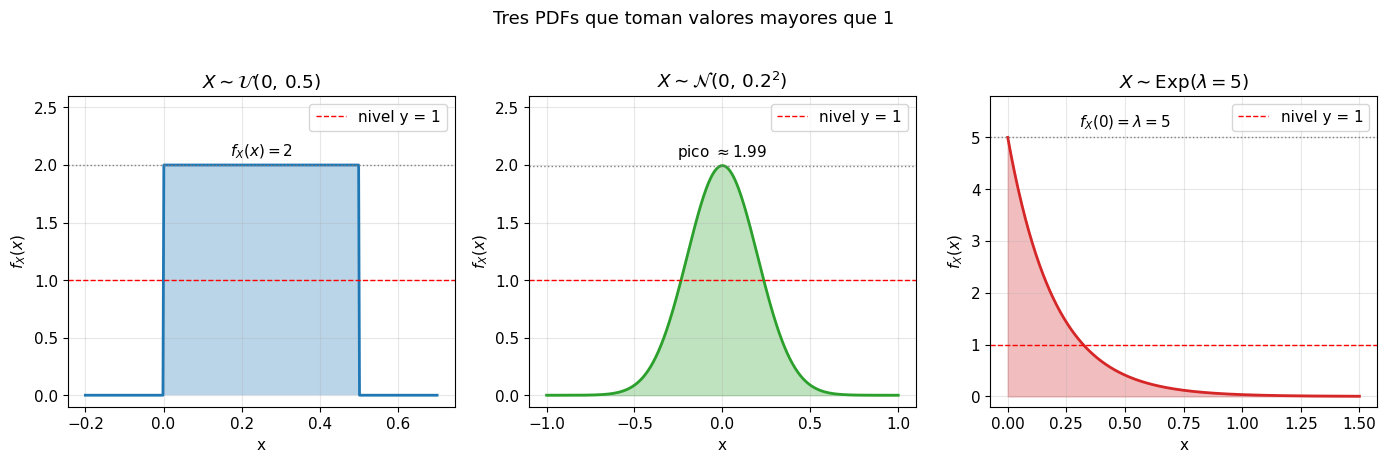

Distribución                máx f(x)    ∫ f(x) dx     P(0≤X≤0.1)
-----------------------------------------------------------------
Uniforme U(0, 0.5)             2.000     1.000000       0.200000
Normal N(0, 0.2²)              1.995     1.000000       0.191462
Exponencial λ=5                5.000     1.000000       0.393469


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# (1) Uniforme U(0, 0.5):  f(x) = 1/(b-a) = 2
U = stats.uniform(loc=0, scale=0.5)
x1 = np.linspace(-0.2, 0.7, 400)
axes[0].plot(x1, U.pdf(x1), color='C0', lw=2)
axes[0].fill_between(x1, U.pdf(x1), alpha=0.3)
axes[0].axhline(1, color='red', ls='--', lw=1, label='nivel y = 1')
axes[0].axhline(2, color='gray', ls=':', lw=1)
axes[0].text(0.25, 2.08, '$f_X(x)=2$', ha='center')
axes[0].set_title(r'$X \sim \mathcal{U}(0,\, 0.5)$')
axes[0].set_xlabel('x'); axes[0].set_ylabel(r'$f_X(x)$')
axes[0].set_ylim(-0.1, 2.6); axes[0].legend(loc='upper right')

# (2) Normal con sigma pequeña: pico = 1/(sigma*sqrt(2pi))
sigma = 0.2
N = stats.norm(loc=0, scale=sigma)
x2 = np.linspace(-1, 1, 400)
axes[1].plot(x2, N.pdf(x2), color='C2', lw=2)
axes[1].fill_between(x2, N.pdf(x2), alpha=0.3, color='C2')
axes[1].axhline(1, color='red', ls='--', lw=1, label='nivel y = 1')
pico = 1/(sigma*np.sqrt(2*np.pi))
axes[1].axhline(pico, color='gray', ls=':', lw=1)
axes[1].text(0, pico+0.08, fr'pico $\approx {pico:.2f}$', ha='center')
axes[1].set_title(r'$X \sim \mathcal{N}(0,\, 0.2^2)$')
axes[1].set_xlabel('x'); axes[1].set_ylabel(r'$f_X(x)$')
axes[1].set_ylim(-0.1, 2.6); axes[1].legend(loc='upper right')

# (3) Exponencial con lambda grande: f(0) = lambda
lam = 5
E = stats.expon(scale=1/lam)
x3 = np.linspace(0, 1.5, 400)
axes[2].plot(x3, E.pdf(x3), color='C3', lw=2)
axes[2].fill_between(x3, E.pdf(x3), alpha=0.3, color='C3')
axes[2].axhline(1, color='red', ls='--', lw=1, label='nivel y = 1')
axes[2].axhline(lam, color='gray', ls=':', lw=1)
axes[2].text(0.5, lam+0.2, fr'$f_X(0)=\lambda={lam}$', ha='center')
axes[2].set_title(r'$X \sim \mathrm{Exp}(\lambda=5)$')
axes[2].set_xlabel('x'); axes[2].set_ylabel(r'$f_X(x)$')
axes[2].set_ylim(-0.2, 5.8); axes[2].legend(loc='upper right')

plt.suptitle('Tres PDFs que toman valores mayores que 1', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Verificación numérica: a pesar de que f(x) > 1, el área total es 1
# y las probabilidades de intervalos siguen siendo ≤ 1
print(f"{'Distribución':<25} {'máx f(x)':>10} {'∫ f(x) dx':>12} {'P(0≤X≤0.1)':>14}")
print("-" * 65)
for nombre, dist, lo, hi, maxf in [
    ('Uniforme U(0, 0.5)',  U, -1,  1,   2.0),
    ('Normal N(0, 0.2²)',   N, -5,  5,   pico),
    ('Exponencial λ=5',     E,  0,  100, 5.0),
]:
    area, _ = integrate.quad(dist.pdf, lo, hi)
    p_int = dist.cdf(0.1) - dist.cdf(0)
    print(f'{nombre:<25} {maxf:>10.3f} {area:>12.6f} {p_int:>14.6f}')

Observe que en los tres casos:

- la PDF supera el nivel $y=1$ (en el primer caso vale 2 en todo el soporte; en el segundo el pico ronda 2; en el tercero la PDF arranca en 5);
- la **integral total sigue siendo exactamente 1**;
- las **probabilidades de intervalos siguen siendo $\leq 1$**.

### 3.1 Interpretación correcta: densidad, no probabilidad

Si $f_X(x_0)$ no es una probabilidad, ¿qué es? Es una **densidad**, en el sentido literal del término. Para $h$ pequeño,
$$\mathbb{P}\!\left(x_0 - \tfrac{h}{2} \leq X \leq x_0 + \tfrac{h}{2}\right) \approx f_X(x_0)\cdot h.$$

La analogía física es la **densidad de masa de un alambre delgado**: si en cierto punto la densidad lineal vale $5\ \mathrm{kg/m}$, eso no significa que ahí haya 5 kg de masa — la masa de un trozo se obtiene multiplicando la densidad por la longitud del trozo (o, si la densidad varía, integrándola). De la misma forma, $f_X(x_0)$ es probabilidad **por unidad de longitud** en el eje $x$, y se convierte en probabilidad genuina solo al integrarla sobre un intervalo.

### 3.2 Resumen de cotas

| Cantidad | ¿Está acotada por 1? |
|---|---|
| $f_X(x)$ | **No** — puede ser arbitrariamente grande, e incluso divergir a $+\infty$ en distribuciones como Beta(0.5, 0.5) o Gamma con $\alpha < 1$. |
| $\int_{-\infty}^{\infty} f_X(x)\,dx$ | **Sí**, vale exactamente 1. |
| $\mathbb{P}(a \leq X \leq b)$ | **Sí**, está en $[0,1]$. |
| $F_X(x)$ | **Sí**, está en $[0,1]$. |

Con esta distinción clara entre **densidad** y **probabilidad**, ya estamos listos para el ejemplo guiado.

## 4. Ejemplo guiado: Distribución Exponencial

Comenzamos con la distribución **Exponencial** de parámetro $\lambda > 0$, cuyas funciones son:

$$f_X(x) = \begin{cases} \lambda e^{-\lambda x}, & x \geq 0 \\ 0, & x < 0 \end{cases}, \qquad F_X(x) = \begin{cases} 1 - e^{-\lambda x}, & x \geq 0 \\ 0, & x < 0 \end{cases}$$

Tomemos $\lambda = \frac{1}{100}$.

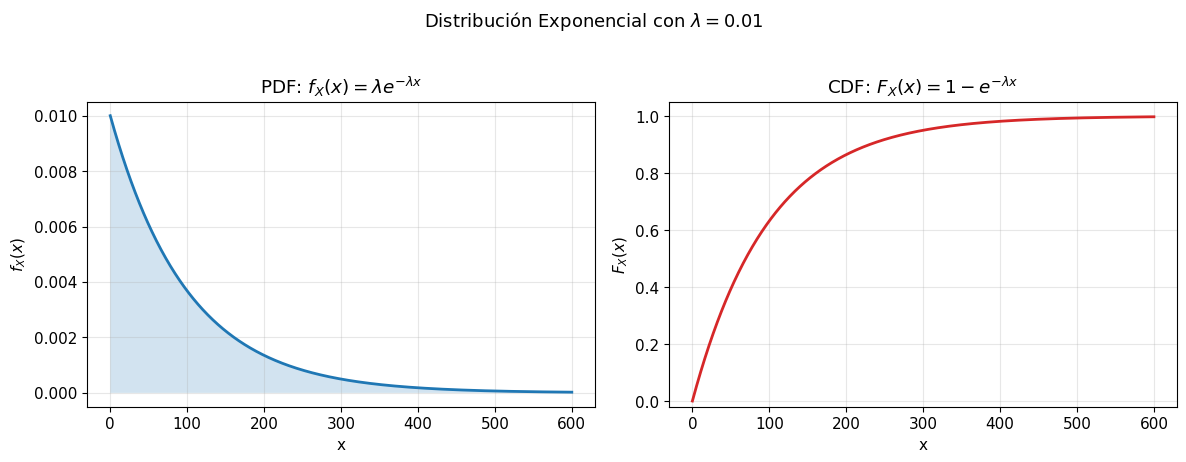

In [11]:
# Parámetro
lam =.01

# scipy parametriza la exponencial mediante 'scale' = 1/lambda
X = stats.expon(scale=1/lam)

#x = np.linspace(0, 5, 400), valores para lam = 1.5
x = np.linspace(0,600,1000)
pdf_vals = X.pdf(x)
cdf_vals = X.cdf(x)

# Gráficas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(x, pdf_vals, color='C0', lw=2)
axes[0].fill_between(x, pdf_vals, alpha=0.2)
axes[0].set_title(r'PDF: $f_X(x) = \lambda e^{-\lambda x}$')
axes[0].set_xlabel('x'); axes[0].set_ylabel(r'$f_X(x)$')

axes[1].plot(x, cdf_vals, color='C3', lw=2)
axes[1].set_title(r'CDF: $F_X(x) = 1 - e^{-\lambda x}$')
axes[1].set_xlabel('x'); axes[1].set_ylabel(r'$F_X(x)$')
axes[1].set_ylim(-0.02, 1.05)

plt.suptitle(f'Distribución Exponencial con $\\lambda = {lam}$', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### 3.1 Visualización de la relación: la CDF acumula área bajo la PDF

La siguiente figura ilustra la idea central. Para un valor $x_0$ fijo, $F_X(x_0)$ es exactamente el **área bajo la PDF** desde $-\infty$ hasta $x_0$.

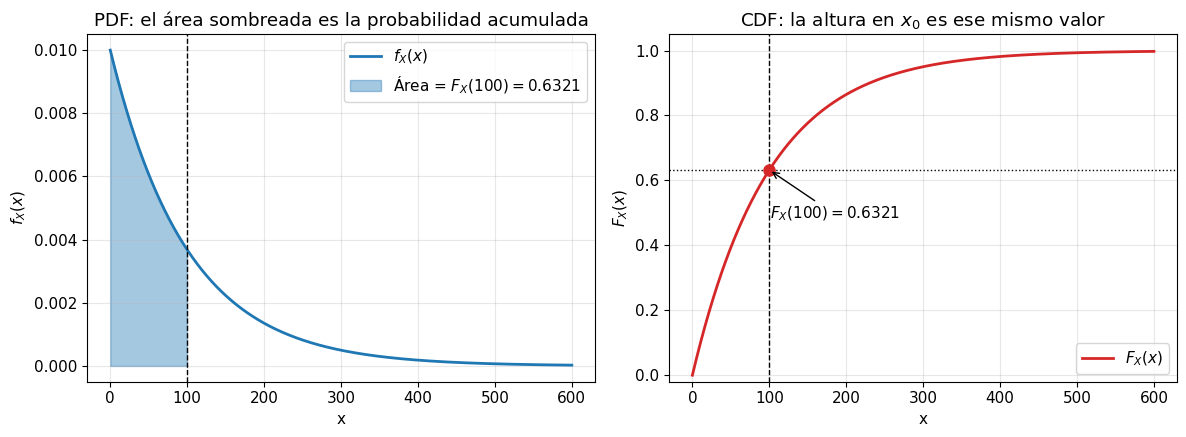

In [12]:
x0 = 100  # punto de evaluación

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# --- Panel izquierdo: PDF con área sombreada hasta x0 ---
axes[0].plot(x, pdf_vals, color='C0', lw=2, label=r'$f_X(x)$')
mask = x <= x0
axes[0].fill_between(x[mask], pdf_vals[mask], alpha=0.4, color='C0',
                     label=fr'Área = $F_X({x0}) = {X.cdf(x0):.4f}$')
axes[0].axvline(x0, color='k', ls='--', lw=1)
axes[0].set_title('PDF: el área sombreada es la probabilidad acumulada')
axes[0].set_xlabel('x'); axes[0].set_ylabel(r'$f_X(x)$')
axes[0].legend()

# --- Panel derecho: CDF marcando el valor en x0 ---
axes[1].plot(x, cdf_vals, color='C3', lw=2, label=r'$F_X(x)$')
axes[1].axvline(x0, color='k', ls='--', lw=1)
axes[1].axhline(X.cdf(x0), color='k', ls=':', lw=1)
axes[1].plot(x0, X.cdf(x0), 'o', color='C3', ms=8)
axes[1].annotate(fr'$F_X({x0}) = {X.cdf(x0):.4f}$',
                 xy=(x0, X.cdf(x0)), xytext=(x0+0.4, X.cdf(x0)-0.15),
                 arrowprops=dict(arrowstyle='->'))
axes[1].set_title('CDF: la altura en $x_0$ es ese mismo valor')
axes[1].set_xlabel('x'); axes[1].set_ylabel(r'$F_X(x)$')
axes[1].set_ylim(-0.02, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.2 Verificación numérica I: integración numérica de la PDF

Vamos a comprobar **a mano** que integrar numéricamente la PDF reproduce la CDF teórica. Usamos `scipy.integrate.quad`.

In [17]:
puntos = [50.0, 100.0, 150.0, 200.0, 250.0, 300.0, 350.0, 400.0, 450.0, 500.0]

print(f"{'x':>5} | {'F_X(x) teórica':>16} | {'∫ f_X dt numérica':>20} | {'|error|':>10}")
print("-" * 65)

for x0 in puntos:
    F_teorica = X.cdf(x0)
    F_numerica, _ = integrate.quad(X.pdf, 0, x0)  # límite inferior 0 porque la PDF se anula en x<0
    print(f"{x0:>5.2f} | {F_teorica:>16.8f} | {F_numerica:>20.8f} | {abs(F_teorica-F_numerica):>10.2e}")

    x |   F_X(x) teórica |    ∫ f_X dt numérica |    |error|
-----------------------------------------------------------------
50.00 |       0.39346934 |           0.39346934 |   5.55e-17
100.00 |       0.63212056 |           0.63212056 |   1.11e-16
150.00 |       0.77686984 |           0.77686984 |   1.11e-16
200.00 |       0.86466472 |           0.86466472 |   1.11e-16
250.00 |       0.91791500 |           0.91791500 |   0.00e+00
300.00 |       0.95021293 |           0.95021293 |   0.00e+00
350.00 |       0.96980262 |           0.96980262 |   1.11e-16
400.00 |       0.98168436 |           0.98168436 |   1.11e-16
450.00 |       0.98889100 |           0.98889100 |   1.11e-16
500.00 |       0.99326205 |           0.99326205 |   1.11e-16


Las dos columnas coinciden hasta el error de cuadratura: efectivamente $F_X(x) = \int_{-\infty}^{x} f_X(t)\,dt$.

### 3.3 Verificación numérica II: derivación numérica de la CDF

Ahora comprobamos la dirección inversa. Aproximamos $\dfrac{d}{dx}F_X(x)$ por **diferencias finitas centradas**:
$$F_X'(x) \approx \dfrac{F_X(x+h) - F_X(x-h)}{2h}.$$

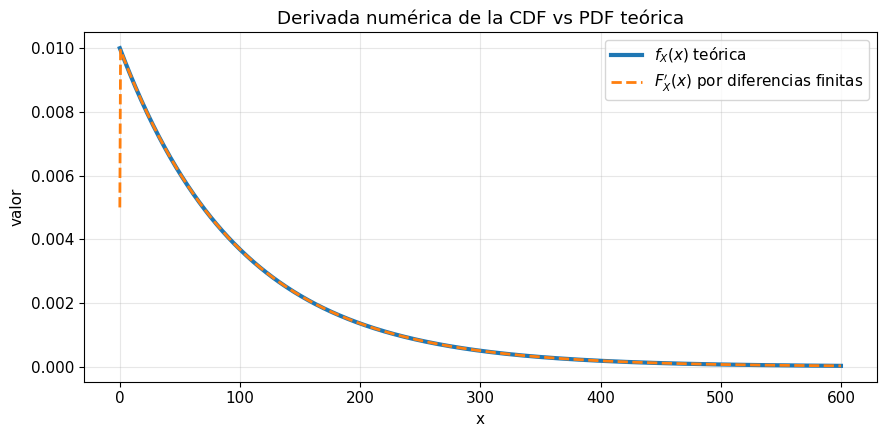

Error máximo entre F'(x) numérica y f(x) teórica: 5.00e-03


In [19]:
# Derivada numérica de la CDF en una malla
xx = np.linspace(0,600,1000)
h = 1e-4
deriv_numerica = (X.cdf(xx + h) - X.cdf(xx - h)) / (2 * h)
pdf_teorica = X.pdf(xx)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(xx, pdf_teorica, lw=3, color='C0', label=r'$f_X(x)$ teórica')
ax.plot(xx, deriv_numerica, '--', lw=2, color='C1', label=r"$F_X'(x)$ por diferencias finitas")
ax.set_title('Derivada numérica de la CDF vs PDF teórica')
ax.set_xlabel('x'); ax.set_ylabel('valor')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Error máximo entre F'(x) numérica y f(x) teórica: {np.max(np.abs(deriv_numerica - pdf_teorica)):.2e}")

Las dos curvas son prácticamente indistinguibles: derivar la CDF recupera la PDF.

### 3.4 Probabilidad de un intervalo: las dos vías

Calculemos $\mathbb{P}(50 \leq X \leq 100)$ de tres maneras y comparemos.

In [20]:
a, b = 50.0, 100.0

# Vía 1: diferencia de la CDF
p_cdf = X.cdf(b) - X.cdf(a)

# Vía 2: integral de la PDF
p_int, _ = integrate.quad(X.pdf, a, b)

# Vía 3: simulación Monte Carlo
muestras = X.rvs(size=200_000)
p_mc = np.mean((muestras >= a) & (muestras <= b))

print(f"P({a} ≤ X ≤ {b}) por F(b) - F(a)        = {p_cdf:.6f}")
print(f"P({a} ≤ X ≤ {b}) por ∫ f(x) dx          = {p_int:.6f}")
print(f"P({a} ≤ X ≤ {b}) por Monte Carlo (N=2e5)= {p_mc:.6f}")

P(50.0 ≤ X ≤ 100.0) por F(b) - F(a)        = 0.238651
P(50.0 ≤ X ≤ 100.0) por ∫ f(x) dx          = 0.238651
P(50.0 ≤ X ≤ 100.0) por Monte Carlo (N=2e5)= 0.238640


Las tres estimaciones coinciden (Monte Carlo con un pequeño error estadístico), confirmando la equivalencia
$$\mathbb{P}(a \leq X \leq b) = F_X(b) - F_X(a) = \int_a^b f_X(x)\,dx.$$

Visualicemos esta probabilidad como área:

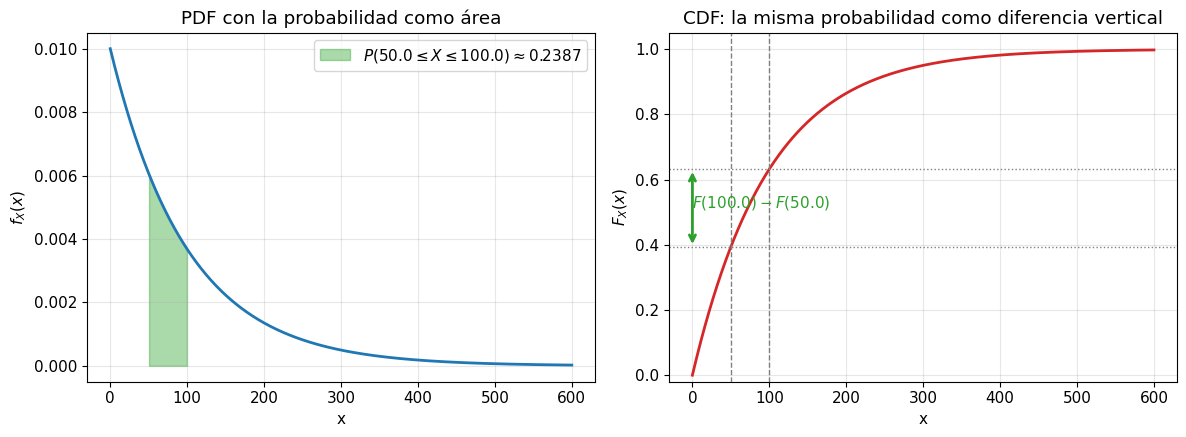

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# PDF con la franja [a,b] sombreada
axes[0].plot(x, pdf_vals, color='C0', lw=2)
mask = (x >= a) & (x <= b)
axes[0].fill_between(x[mask], pdf_vals[mask], alpha=0.4, color='C2',
                     label=fr'$P({a}\leq X \leq {b}) \approx {p_int:.4f}$')
axes[0].set_title('PDF con la probabilidad como área')
axes[0].set_xlabel('x'); axes[0].set_ylabel(r'$f_X(x)$')
axes[0].legend()

# CDF mostrando la diferencia F(b) - F(a)
axes[1].plot(x, cdf_vals, color='C3', lw=2)
for v, color in [(a, 'gray'), (b, 'gray')]:
    axes[1].axvline(v, color=color, ls='--', lw=1)
    axes[1].axhline(X.cdf(v), color=color, ls=':', lw=1)
axes[1].annotate('', xy=(0.05, X.cdf(b)), xytext=(0.05, X.cdf(a)),
                 arrowprops=dict(arrowstyle='<->', color='C2', lw=2))
axes[1].text(0.15, (X.cdf(a)+X.cdf(b))/2, fr'$F({b})-F({a})$', color='C2')
axes[1].set_title('CDF: la misma probabilidad como diferencia vertical')
axes[1].set_xlabel('x'); axes[1].set_ylabel(r'$F_X(x)$')
axes[1].set_ylim(-0.02, 1.05)

plt.tight_layout()
plt.show()

## 5. Comparación entre distribuciones

Repitamos el ejercicio para tres distribuciones clásicas y observemos sus PDF y CDF en paralelo:

| Distribución | Notación | PDF | CDF |
|---|---|---|---|
| Uniforme | $\mathcal{U}(a,b)$ | $\dfrac{1}{b-a}\mathbf{1}_{[a,b]}(x)$ | $\dfrac{x-a}{b-a}$ en $[a,b]$ |
| Exponencial | $\mathrm{Exp}(\lambda)$ | $\lambda e^{-\lambda x}\mathbf{1}_{x\geq 0}$ | $1 - e^{-\lambda x}$ |
| Normal | $\mathcal{N}(\mu,\sigma^2)$ | $\dfrac{1}{\sigma\sqrt{2\pi}} e^{-(x-\mu)^2/(2\sigma^2)}$ | $\Phi\!\left(\dfrac{x-\mu}{\sigma}\right)$ |

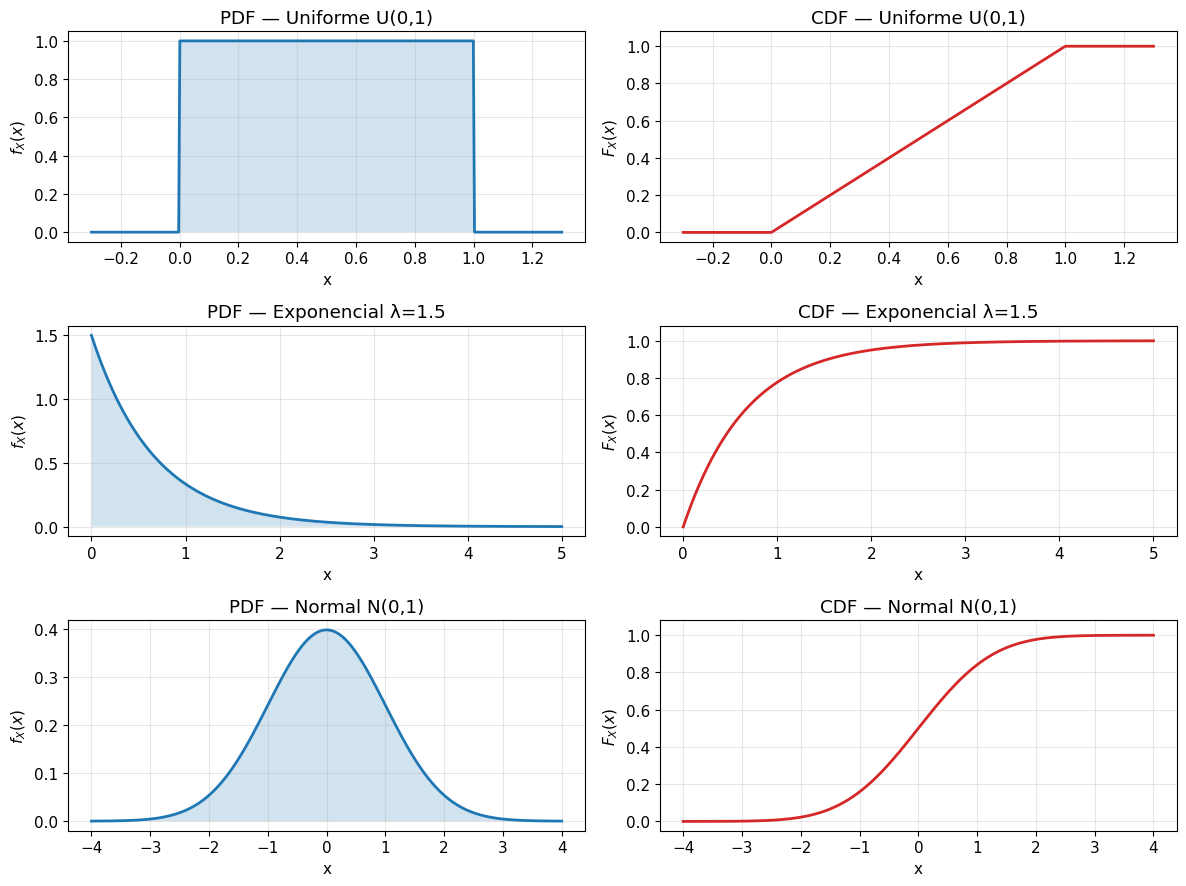

In [9]:
distribuciones = {
    'Uniforme U(0,1)':   (stats.uniform(loc=0, scale=1),    np.linspace(-0.3, 1.3, 400)),
    'Exponencial λ=1.5': (stats.expon(scale=1/1.5),          np.linspace(0,    5,    400)),
    'Normal N(0,1)':     (stats.norm(loc=0, scale=1),        np.linspace(-4,   4,    400)),
}

fig, axes = plt.subplots(len(distribuciones), 2, figsize=(12, 9))

for i, (nombre, (dist, grid)) in enumerate(distribuciones.items()):
    axes[i,0].plot(grid, dist.pdf(grid), color='C0', lw=2)
    axes[i,0].fill_between(grid, dist.pdf(grid), alpha=0.2)
    axes[i,0].set_title(f'PDF — {nombre}')
    axes[i,0].set_xlabel('x'); axes[i,0].set_ylabel(r'$f_X(x)$')
    
    axes[i,1].plot(grid, dist.cdf(grid), color='C3', lw=2)
    axes[i,1].set_title(f'CDF — {nombre}')
    axes[i,1].set_xlabel('x'); axes[i,1].set_ylabel(r'$F_X(x)$')
    axes[i,1].set_ylim(-0.05, 1.08)

plt.tight_layout()
plt.show()

**Lectura comparativa.** Note cómo los rasgos de cada PDF se traducen en su CDF:

- *Uniforme:* PDF constante $\Rightarrow$ CDF lineal en el soporte.
- *Exponencial:* PDF decreciente desde $\lambda$ $\Rightarrow$ CDF cóncava que crece más rápido al inicio.
- *Normal:* PDF simétrica con un máximo en $\mu$ $\Rightarrow$ CDF con forma de "S" y punto de inflexión justo en $\mu$ (donde la pendiente es máxima).

Este último punto es clave: **el punto donde la CDF crece más rápido es donde la PDF alcanza su máximo**, porque la PDF es la derivada de la CDF.

## 6. Histograma vs PDF, ECDF vs CDF

Una buena forma de internalizar la relación es generar muestras de la variable y comparar los estimadores empíricos con las funciones teóricas:

- el **histograma normalizado** estima la PDF,
- la **función de distribución empírica (ECDF)** estima la CDF.

$$\hat{F}_n(x) = \dfrac{1}{n}\sum_{i=1}^n \mathbf{1}\{X_i \leq x\}.$$

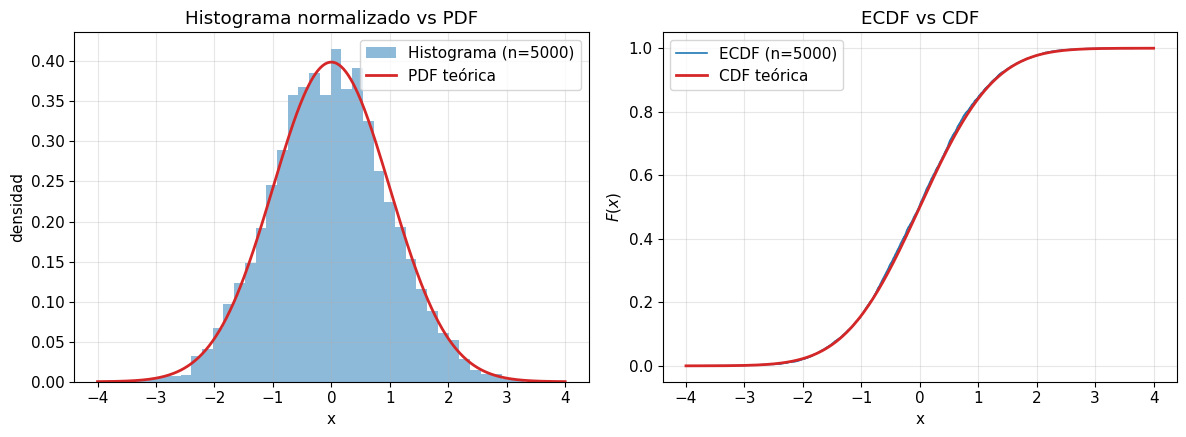

In [10]:
n = 5000
Z = stats.norm(loc=0, scale=1)
muestra = Z.rvs(size=n)

grid = np.linspace(-4, 4, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Histograma vs PDF
axes[0].hist(muestra, bins=40, density=True, alpha=0.5, color='C0', label='Histograma (n=5000)')
axes[0].plot(grid, Z.pdf(grid), color='C3', lw=2, label='PDF teórica')
axes[0].set_title('Histograma normalizado vs PDF')
axes[0].set_xlabel('x'); axes[0].set_ylabel('densidad')
axes[0].legend()

# ECDF vs CDF
muestra_ord = np.sort(muestra)
ecdf = np.arange(1, n+1) / n
axes[1].step(muestra_ord, ecdf, where='post', color='C0', lw=1.2, label='ECDF (n=5000)')
axes[1].plot(grid, Z.cdf(grid), color='C3', lw=2, label='CDF teórica')
axes[1].set_title('ECDF vs CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel(r'$F(x)$')
axes[1].legend()

plt.tight_layout()
plt.show()

Cuando $n\to\infty$, el **Teorema de Glivenko–Cantelli** garantiza que la ECDF converge uniformemente casi seguramente a la CDF: $\sup_x |\hat{F}_n(x) - F_X(x)| \xrightarrow{c.s.} 0.$

---

## 7. Ejercicios para el estudiante

Resuelva cada ejercicio en una celda nueva, mezclando código y celdas de **markdown** con explicaciones y deducciones a mano cuando se solicite.

### Ejercicio 1 — Distribución uniforme (analítico + numérico)

Sea $X \sim \mathcal{U}(2, 7)$.

1. Escriba **explícitamente** $f_X$ y $F_X$ por casos (en una celda markdown con LaTeX).
2. Implemente ambas funciones a mano (sin usar `scipy.stats.uniform`) y grafíquelas en $[0, 9]$.
3. Calcule $\mathbb{P}(3 \leq X \leq 5)$ por las tres vías (CDF, integración numérica de la PDF, Monte Carlo) y verifique que coinciden.

### Ejercicio 2 — Construir una PDF

Considere
$$f_X(x) = c \, x (1-x), \qquad x \in [0,1],$$
y $f_X(x)=0$ fuera de $[0,1]$.

1. Determine analíticamente el valor de $c$ para que $f_X$ sea una PDF válida.
2. Calcule analíticamente $F_X(x)$ para $x \in [0,1]$.
3. Verifique con código (integrando numéricamente y derivando numéricamente la CDF) sus resultados.
4. Calcule $\mathbb{P}(X \leq 0.3)$ y $\mathbb{P}(0.2 \leq X \leq 0.8)$.

### Ejercicio 3 — De la CDF a la PDF

Suponga que se le entrega únicamente la CDF
$$F_X(x) = \begin{cases} 0, & x < 0 \\ x^2, & 0 \leq x \leq 1 \\ 1, & x > 1 \end{cases}$$

1. Verifique analíticamente que $F_X$ es una CDF válida (no decreciente, continua, límites correctos).
2. Obtenga $f_X$ derivando $F_X$ y grafíquela.
3. Recupere $f_X$ **numéricamente** por diferencias finitas a partir de $F_X$ y compare con la fórmula analítica.

### Ejercicio 4 — Comparación de colas

Considere $X \sim \mathcal{N}(0,1)$ y $Y \sim \mathrm{Exp}(1)$.

1. Calcule numéricamente $\mathbb{P}(X > 3)$ y $\mathbb{P}(Y > 3)$.
2. Grafique ambas CDF en una misma figura, restringiéndose a $x \in [0, 6]$. ¿Cuál se acerca más rápido a 1?
3. Discuta brevemente, en una celda de markdown, el concepto de "colas pesadas" comparando las dos PDF en escala logarítmica.

### Ejercicio 5 — ECDF y convergencia

Para $X \sim \mathrm{Exp}(2)$:

1. Para $n \in \{20, 200, 2000, 20000\}$, simule una muestra y grafique la ECDF junto con la CDF teórica (cuatro paneles).
2. Calcule $D_n = \sup_x |\hat{F}_n(x) - F_X(x)|$ para cada $n$ (ayuda: evalúe el supremo sobre los puntos de la muestra).
3. Grafique $D_n$ contra $n$ en escala log-log. ¿Qué pendiente espera, según el resultado de Dvoretzky–Kiefer–Wolfowitz, $D_n = O(n^{-1/2})$?

## 8. Resumen

- La PDF $f_X$ y la CDF $F_X$ contienen **la misma información** sobre la distribución de $X$, expresada de dos formas distintas.
- Están conectadas por el cálculo:
$$F_X(x) = \int_{-\infty}^x f_X(t)\,dt, \qquad f_X(x) = F_X'(x).$$
- Toda probabilidad de un intervalo se puede calcular **igual de bien** integrando la PDF o restando valores de la CDF.
- Numéricamente, esta relación se puede verificar con `scipy.integrate.quad` (para integrar) y diferencias finitas (para derivar).
- Empíricamente, el **histograma** estima la PDF y la **ECDF** estima la CDF; ambos convergen a sus contrapartes teóricas conforme crece la muestra.

En la siguiente práctica usaremos estas herramientas para estudiar **esperanza, varianza y momentos** de variables aleatorias continuas.